In [1]:
from qitf_model import *
import numpy as np

exact_model = QITFModel(hx=0.809,J=1)
# analog_model = analog_QITF(exact_model,0.01)

import pickle
# with open('./Figures/analog_model.pkl', 'wb') as f:
#     pickle.dump(analog_model, f)

with open('./Figures/analog_model.pkl', 'rb') as f:
    analog_model = pickle.load(f)

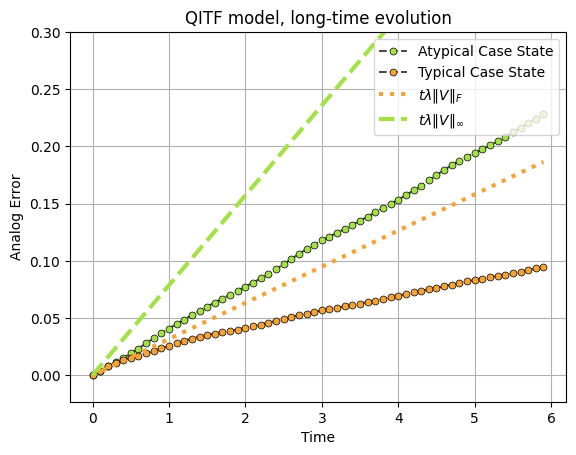

In [2]:
initial_state=Statevector.from_label('+'*N).data
    # analog_model.plot_one_segment(initial_state, mfc='#66C999', label='Separable State')
analog_model.plot_long_time(initial_state, mfc="#A4E048", label='Atypical Case State')

# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
analog_model.plot_long_time(initial_state, mfc='#F3A33A', label='Typical Case State')

fro_curve=[]
spec_curve=[]
V_fro = np.linalg.norm(analog_model.perm, 'fro')/sqrt(d)
V_spec = np.linalg.norm(analog_model.perm, 2)
for t in time:
    fro_curve.append(t*V_fro)
    spec_curve.append(t*V_spec)
plt.plot(time[:-1], fro_curve[:-1], color='#F3A33A', linestyle='dotted', label=r'$t\lambda\|V\|_{F}$',linewidth=3)
plt.plot(time[:-1], spec_curve[:-1], color='#A4E048', linestyle='dashed', label=r'$t\lambda\|V\|_{\infty}$',linewidth=3)
    # plt.plot(time[:-1], [V_fro*time_step]*num_steps, color='#397FC7', linestyle='dotted', label=r'$\delta t\lambda\|V\|_{F}$')
    # plt.plot(time[:-1], scrambling_value,color='0.3',marker='o',markersize=5,mfc='#66C999',mec='k',linestyle='dashed',markeredgewidth=0.5)
    # plt.plot(time[:-1], simulation_error_state,color='0.3',mfc='#5DBFE9',marker='o',markersize=5,mec='k',linestyle='dashed',markeredgewidth=0.5)
    # plt.plot(time[:-1], [average_case_commutator]*num_steps,color='#66C999',linestyle='dashed')
    # plt.plot(time[:-1], [Fro_bound]*num_steps,color='#397FC7',linestyle='dotted')
plt.xlabel('Time')
plt.ylabel('Analog Error')
plt.ylim( top=0.3)
plt.legend(loc=1)
plt.title('QITF model, long-time evolution')
plt.grid()
plt.savefig('./Figures/long-time.pdf', bbox_inches='tight',dpi=600)
plt.show()

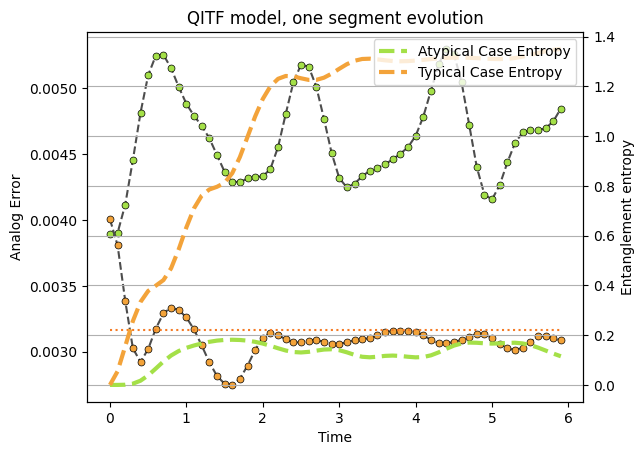

In [3]:
from entropy import entropy_data
import matplotlib.pyplot as plt

initial_state=Statevector.from_label('+'*N).data
fig, ax1 =plt.subplots()
state_distance = []
exact_state = initial_state
analog_state = initial_state
for i in range(num_steps):    
    analog_state = analog_model.U0 @ exact_state
    exact_state = analog_model.exact_model.U0 @ exact_state
    state_distance.append(np.linalg.norm(exact_state - analog_state))
p11=ax1.plot(time[:-1], state_distance, color='0.3', marker='o', markersize=5, mfc='#A4E048', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Atypical Case State')
ax2=ax1.twinx()
entropy_list=entropy_data(initial_state, analog_model, k=2)
p12=ax2.plot(time[:-1], entropy_list[:-1], color='#A4E048',linestyle='dashed',label='Atypical Case Entropy',linewidth=3)


# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
state_distance = []
exact_state = initial_state
analog_state = initial_state
for i in range(num_steps):    
    analog_state = analog_model.U0 @ exact_state
    exact_state = analog_model.exact_model.U0 @ exact_state
    state_distance.append(np.linalg.norm(exact_state - analog_state))
p21=ax1.plot(time[:-1], state_distance, color='0.3', marker='o', markersize=5, mfc='#F3A33A', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Typical Case State')

entropy_list=entropy_data(initial_state, analog_model, k=2)
p22=ax2.plot(time[:-1], entropy_list[:-1], color='#F3A33A',linestyle='dashed',label='Typical Case Entropy',linewidth=3)


ax1.plot(time[:-1], [V_fro*time_step]*num_steps, color="#F57B25", linestyle='dotted', label=r'$\delta t\lambda\|V\|_{F}$')
# plt.plot(time[:-1], [V_spec*time_step]*num_steps, color='#A4E048', linestyle='dashed', label=r'$\delta t\lambda\|V\|_{\infty}$')
ax1.set_xlabel('Time')
ax1.set_ylabel('Analog Error')
ax2.set_ylabel('Entanglement entropy')
plt.title('QITF model, one segment evolution')
plt.legend(loc=1)
plt.grid()
plt.savefig('./Figures/one_segment.pdf', bbox_inches='tight',dpi=600)
plt.show()

In [4]:
import pickle
with open('./data/analog_model.pkl', 'wb') as f:
    pickle.dump(analog_model, f)